In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import mat73
import pickle
import pandas as pd
import pingouin as pg
import xarray as xr
from globals import behavDir
from util import hedges_g

import pandas as pd
from lfp import make_freq_masks
import globals as gl

import seaborn as sb
import PcmPy as pcm
from scipy.stats import norm
plt.style.use('default')

In [3]:
### colours ###
cmap_plan = plt.get_cmap('Greys')
col_plan = [cmap_plan(i) for i in np.linspace(.3, .9, 5)]

cmap_index = plt.get_cmap('Greens')
col_index = [cmap_index(i) for i in np.linspace(.3, .9, 5)][:4]

cmap_ring = plt.get_cmap('Oranges')
col_ring = [cmap_ring(i) for i in np.linspace(.3, .9, 5)][1:]

colour_mapping = {
    '100-0%': col_plan[0],
    '75-25%': col_plan[1],
    '50-50%': col_plan[2],
    '25-75%': col_plan[3],
    '0-100%': col_plan[4],
    '100-0%,ext': col_index[0],
    '75-25%,ext': col_index[1],
    '50-50%,ext': col_index[2],
    '25-75%,ext': col_index[3],
    '75-25%,flx': col_ring[0],
    '50-50%,flx': col_ring[1],
    '25-75%,flx': col_ring[2],
    '0-100%,flx': col_ring[3],
}

###############

In [4]:
baseDir = '/cifs/pruszynski/Marco/SensoriMotorPrediction'
lfpDir = 'LFPs' #+ monkey + '/'
spkDir = 'spikes' #+ monkey + '/'
pcmDir = 'pcm'
behavDir = 'Behavioural'
recDir = 'Recordings'
cfg = mat73.loadmat(os.path.join(baseDir, lfpDir,'Malfoy/cfg.PMd-19.mat'))['cfg']
foi = cfg['foi']
freq_masks = make_freq_masks(cfg)

freqs = ['delta', 'theta', 'alpha-beta', 'gamma']
recordings = {
            'Malfoy': {
                'PMd': [10, 13, 14, 15, 16, 17, 19, 20, 21, 22, 23, 24],
                'M1': [12, 13, 25, 27, 28],
                'S1': [11, 15, 16, 26, 27, 28]
            },
            'Pert': {
                'PMd': [4, 6, 7, 10, 20],
                'M1': [2, 3, 14, 20],
                'S1': [15]
            }
        }

cuePre = 0
cueIdx = 20
cuePost = 84
pertPre = cuePost
pertIdx = pertPre + 30
pertPost = pertPre + 70

t_cue = np.linspace(0, cuePost - 1, cuePost)
t_pert = np.linspace(pertPre, pertPost - 1, pertPost - pertPre) + 5
t = np.concatenate((t_cue, t_pert))

monkey = ['Malfoy', 'Pert']

rois = ['PMd', 'M1', 'S1']
freq = freq_masks['alpha-beta']

var_expl = {"lfp": [], "spk": [], 'roi': []}  # each becomes list over rois
kin = {"elbow": [], "prob": [], 'cond': [], 'rec': [], 'roi': []}
corr = {"lfp": [], "spk": [], 'roi': []}
epoch = 'plan'
for roi in rois:
    for mon in monkey:
        for rec in recordings[mon][roi]:
            theta_lfp_comp = np.load(os.path.join(baseDir, pcmDir, mon, f'theta_in.lfp.component.{roi}.{epoch}-{rec}.npy'))
            theta_spk_comp = np.load(os.path.join(baseDir, pcmDir, mon, f'theta_in.spk.component.{roi}.{epoch}-{rec}.npy'))
            elb = np.load(os.path.join(baseDir, behavDir, mon, f'kin_aligned-{rec}.npy'))
            tinfo = pd.read_csv(os.path.join(baseDir, recDir, mon, f'trial_info-{rec}.tsv'), sep='\t')
            tinfo = tinfo[(tinfo['isCatch']==0) & (tinfo['AdaptationBlock']==0)]
            mapping = {1: 1, 2: 8, 3: 3, 4: 6, 5: 2, 6: 5, 7: 4, 8: 7}
            tinfo.cond = tinfo.cond.map(mapping)
            kin['elbow'].append(elb.T)
            kin['prob'].append(tinfo['prob'])
            kin['cond'].append(tinfo['cond'])
            kin['rec'].extend([f'{mon}-{rec}'] * tinfo['cond'].shape[0])
            kin['roi'].extend([roi] * tinfo['cond'].shape[0])
            var_expl["lfp"].append(np.exp(theta_lfp_comp[...,:-1]))
            var_expl["spk"].append(np.exp(theta_spk_comp[:, :-1]))
            var_expl["roi"].append(roi)

var_expl_lfp_plan = xr.DataArray(data=np.stack(var_expl["lfp"]),
                   dims=('roi', 'freq', 'time', 'model'),
                   coords={
                       'roi': var_expl['roi'],
                       'freq': foi,
                       'time': t,
                       'model': ['cue', 'uncertainty']})
var_expl_spk_plan = xr.DataArray(data=np.stack(var_expl["spk"]),
                   dims=('roi', 'time', 'model'),
                   coords={
                       'roi': var_expl['roi'],
                       'time': t,
                       'model': ['cue', 'uncertainty']})

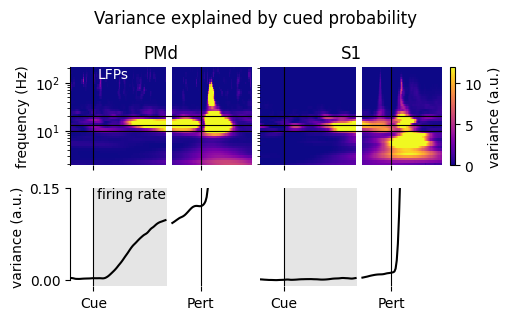

In [5]:
fig, axs_ = plt.subplots(2, 3, sharex='col', figsize=(5, 3), gridspec_kw={"width_ratios": [80, 80, 2]}, constrained_layout=True)

axs = axs_[:, :-1]
ax_c = axs_[:, -1]

vmin, vmax = 0, 12
color = [['darkred', 'navy'], ['lightcoral', 'lightblue']]
label = ['cue', 'uncertainty']
for r, roi in enumerate(['PMd', 'S1']):
    tf1 = var_expl_lfp_plan.sel(roi=roi, time=slice(0, cuePost-1), model='cue').mean(dim='roi').values
    tf2 = var_expl_lfp_plan.sel(roi=roi, time=slice(pertPre, None), model='cue').mean(dim='roi').values
    h = axs[0, r].pcolormesh(t_cue, foi, tf1, vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, r].pcolormesh(t_pert, foi, tf2, vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, r].set_yscale('log')
    axs[0, r].set_title(roi)
    axs[0, r].axhline(10, color='k', lw='.8')
    axs[0, r].axhline(13, color='k', lw='.8')
    axs[0, r].axhline(20, color='k', lw='.8')
    axs[0, r].set_ylabel('frequency (Hz)') if r==0 else None
    act1 = var_expl_spk_plan.sel(roi=roi,time=slice(0, cuePost-1), model='cue').mean(dim='roi').values
    act2 = var_expl_spk_plan.sel(roi=roi, time=slice(pertPre, None), model='cue').mean(dim='roi').values
    axs[1, r].plot(t_cue, act1, color='k')
    axs[1, r].plot(t_pert, act2, color='k')
    axs[1, r].axvspan(cueIdx, cuePost, color='grey', alpha=.2, lw=0)
    axs[1, r].set_ylim([-.01, .15])
    axs[1, r].set_yticks((0, .15))
    axs[1, r].spines['left'].set_bounds(0, .15)
    axs[1, r].set_ylabel('variance (a.u.)') if r==0 else None
    for i in range(2):
        axs[i, r].axvline(cueIdx, color='k', lw='.8')
        axs[i, r].axvline(pertIdx, color='k', lw='.8')
        axs[i, r].set_xticks([cueIdx, pertIdx])
        axs[i, r].set_xticklabels(['Cue', 'Pert'])
        axs[i, r].set_yticks([]) if r>0 else None
        axs[i, r].spines[['bottom', 'right', 'top']].set_visible(False) if r==0 else axs[i, r].spines[['bottom', 'right', 'top', 'left']].set_visible(False)

axs[0, 0].text(.15, 1, 'LFPs', transform=axs[0, 0].transAxes, ha='left', va='top', color='w')
axs[1, 0].text(.15, 1, 'firing rate', transform=axs[1, 0].transAxes, ha='left', va='top')

fig.colorbar(h, cax=ax_c[0], label='variance (a.u.)')
for ax in ax_c[1:]:
    ax.remove()

fig.suptitle(f'Variance explained by cued probability', va='center')

plt.show()

Z = -2.06562803116514 p = 0.038863615541857355


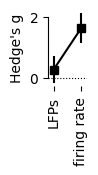

In [6]:
pmd_lfp = var_expl_lfp_plan.sel(roi='PMd', time=slice(cueIdx, cuePost), model='cue', freq=slice(10, 20)).mean(dim=('freq', 'time')).values
s1_lfp = var_expl_lfp_plan.sel(roi='S1', time=slice(cueIdx, cuePost), model='cue', freq=slice(10, 20)).mean(dim=('freq', 'time')).values
pmd_spk = var_expl_spk_plan.sel(roi='PMd', time=slice(cueIdx, cuePost), model='cue').mean(dim=('time')).values
s1_spk = var_expl_spk_plan.sel(roi='S1', time=slice(cueIdx, cuePost), model='cue').mean(dim=('time')).values
hedges_lfp = hedges_g(pmd_lfp, s1_lfp)
hedges_spk = hedges_g(pmd_spk, s1_spk)
g_lfp = hedges_lfp['g']
g_err_lfp = hedges_lfp['se']
g_spk = hedges_spk['g']
g_err_spk = hedges_spk['se']

fig, ax = plt.subplots(figsize=(.5, 1))
ax.errorbar(['LFPs', 'firing rate'], np.r_[g_lfp, g_spk], yerr=np.r_[g_err_lfp, g_err_spk], marker='s', color='k')
ax.axhline(0, color='k', lw=.8, ls=':')
ax.set_xlim(-.2, 1.2)
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.spines[['left']].set_bounds(0, 2)
ax.set_ylabel("Hedge's g")
ax.set_xticklabels(['LFPs', 'firing rate'], rotation=90)

Z = (g_lfp - g_spk) / np.sqrt(g_err_lfp**2 + g_err_spk**2)
p = 2 * (1 - norm.cdf(abs(Z)))

print("Z =", Z, "p =", p)

plt.show()

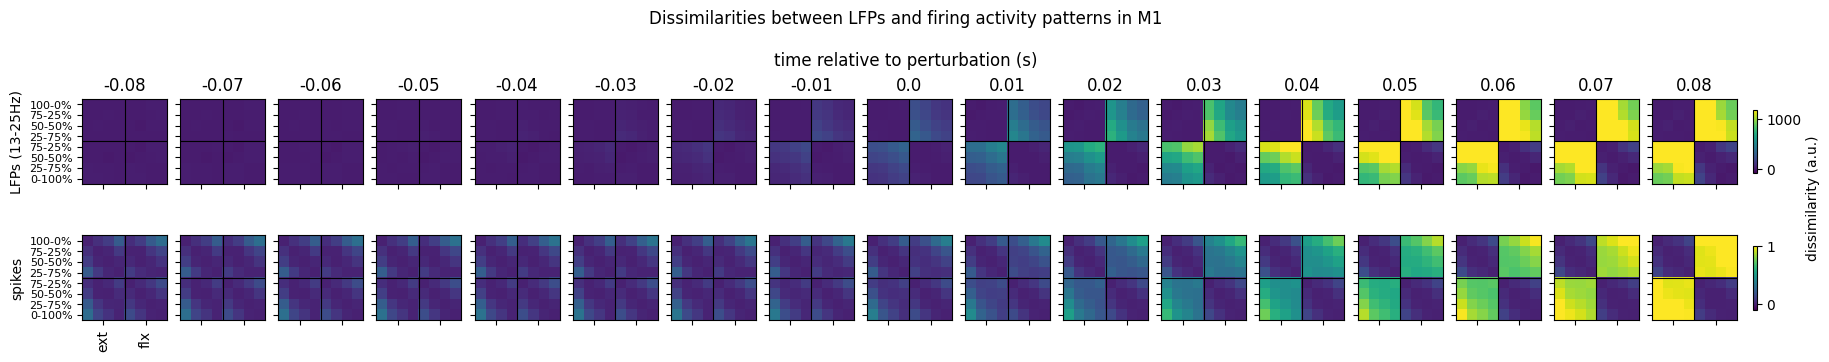

In [72]:
D_lfp, D_spk = [], []
for mon in monkey:
    for rec in recordings[mon]['M1']:
        G_lfp = np.load(os.path.join(baseDir, pcmDir, mon, f'G_obs.lfp.M1.exec-{rec}.npy'))
        freq = freq_masks['beta']
        G_lfp = G_lfp[freq].mean(axis=0)
        G_spk = np.load(os.path.join(baseDir, pcmDir, mon, f'G_obs.spk.M1.exec-{rec}.npy'))
        D_lfp.append(pcm.G_to_dist(G_lfp))
        D_spk.append(pcm.G_to_dist(G_spk))
D_lfp, D_spk = np.array(D_lfp).mean(axis=0), np.array(D_spk).mean(axis=0)
n_timep = 17
timep = np.linspace(-8, 8, n_timep, dtype=int)
fig, axs = plt.subplots(2, n_timep, figsize=(18, 3.5), sharex=True, sharey=True, constrained_layout=True)
for i in range(n_timep):
    ax = axs[:, i]
    ax[0].imshow(D_lfp[pertIdx+timep[i]], vmin=-100, vmax=1200)
    ax[1].imshow(D_spk[pertIdx+timep[i]], vmin=-.1, vmax=1)
    ax[0].set_title(timep[i] / 100)
    ax[0].set_yticks(np.arange(0, 8))
    ax[0].set_xticks(np.arange(1.5, 9.5, 4))
    ax[1].tick_params(labelbottom=False, labelleft=False)
    ax[0].tick_params(labelleft=False)
    for j in range(2):
        ax[j].axhline(3.5, color='k', lw='.8')
        ax[j].axvline(3.5, color='k', lw='.8')

axs[0, 0].set_ylabel('LFPs (13-25Hz)')
axs[1, 0].set_ylabel('spikes')
axs[0, 0].tick_params(labelleft=True)
axs[0, 0].set_yticklabels(['100-0%', '75-25%', '50-50%', '25-75%', '75-25%', '50-50%', '25-75%', '0-100%'], fontsize=8)
axs[1, 0].set_yticklabels(['100-0%', '75-25%', '50-50%', '25-75%', '75-25%', '50-50%', '25-75%', '0-100%'], fontsize=8)
axs[1, 0].set_xticklabels(['ext', 'flx'], rotation=90)
axs[1, 0].tick_params(labelbottom=True, labelleft=True)
fig.suptitle('Dissimilarities between LFPs and firing activity patterns in M1\n\ntime relative to perturbation (s)')
cax = axs[0, -1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs[0], orientation='vertical', fraction=.01, shrink=.5, pad=.01)
cax = axs[1, -1].get_images()[0]
cbar = fig.colorbar(cax, ax=axs[1], orientation='vertical', fraction=.01, shrink=.5, pad=.01)
fig.text(1, .45, 'dissimilarity (a.u.)', va='center', rotation='vertical', ha='left')

plt.show()

0
group estimate:-0.8449282287729698 central 90% CI for r: [-1.000, -0.628]
1
group estimate:0.43160774176752636 central 90% CI for r: [0.318, 0.520]


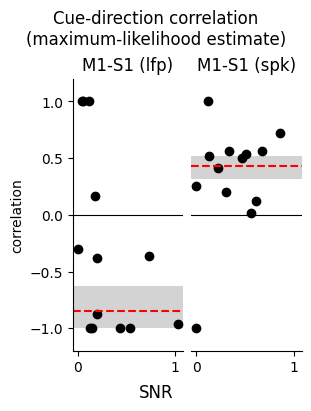

In [13]:
from vis import plot_pcm_corr

f = open(os.path.join(gl.baseDir, 'smp2', gl.pcmDir, f'M.plan-exec.p'), "rb")
Mflex = pickle.load(f)
dtype = ['lfp', 'spk']
fig, axs = plt.subplots(1, len(dtype), sharex=True, sharey=True, constrained_layout=True, figsize=(3, 4))

for d, dt in enumerate(dtype):
    print(d)
    f = open(os.path.join(baseDir, pcmDir, f'theta_in.{dt}.corr_cue-dir.M1-S1.p'), 'rb')
    theta = pickle.load(f)[0]
    r_bootstrap = np.load(os.path.join(baseDir, pcmDir, f'r_bootstrap.{dt}.corr_cue-dir.M1-S1.npy'))
    f = open(os.path.join(baseDir, pcmDir, f'theta_gr.{dt}.corr_cue-dir.M1-S1.p'), 'rb')
    theta_g = pickle.load(f)[0]
    fig, axs = plot_pcm_corr(fig, axs, d, Mflex, theta, theta_g, r_bootstrap)
    axs[d].set_title(f'M1-S1 ({dt})')

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Cue-direction correlation\n(maximum-likelihood estimate)')

plt.show()


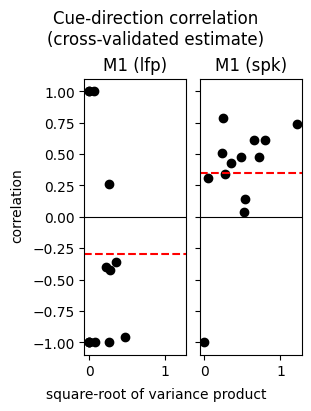

In [12]:
fig, axs = plt.subplots(1, len(dtype), sharex=True, sharey=True, constrained_layout=True, figsize=(3, 4))
for d, dt in enumerate(dtype):
    ax = axs[d]
    G = np.load(os.path.join(baseDir, pcmDir, f'G_obs.{dt}.corr_cue-dir.M1-S1.npy'))
    cov = G[:, 0, 1]
    var1 = np.clip(G[:, 0, 0], 0, None)
    var2 = np.clip(G[:, 1, 1], 0, None)
    corr = np.clip(cov / np.sqrt(var1 * var2) + 1e-6, -1, 1)
    ax.axhline(corr.mean(), color='r', ls='--')
    ax.axhline(0, color='k', lw=.8)
    ax.scatter(np.sqrt(var1 * var2), corr, color='k')
    ax.set_title(f'M1 ({dt})')

fig.suptitle('Cue-direction correlation\n(cross-validated estimate)')
fig.supxlabel('square-root of variance product', fontsize=10)
fig.supylabel('correlation', fontsize=10)
# fig.tight_layout()

plt.show()